I constructed a small synthetic dataset of 20 short food-preference texts.
Each text is treated as one document, which will later be converted into a vector representation and used to build a similarity graph.

In [3]:
import pandas as pd

reviews = [
    "I like apple banana grape mango",
    "I enjoy banana orange mango papaya",
    "I love strawberry blueberry raspberry cherry",
    "I prefer lemon orange lime grapefruit",

    "I like salmon tuna shrimp crab",
    "I enjoy lobster scallop oyster fish",
    "I love sushi tuna salmon seaweed",
    "I prefer shrimp crab lobster garlic",

    "I like beef steak pork lamb",
    "I enjoy chicken beef barbecue ribs",
    "I love bacon sausage burger fries",
    "I prefer roast beef pork chop",

    "I like pizza pasta tomato cheese",
    "I enjoy noodles dumplings tofu kimchi",
    "I love curry rice noodles ramen",
    "I prefer fried rice tofu vegetables",

    "I like chocolate cake cookie brownie",
    "I enjoy ice cream vanilla chocolate",
    "I love coffee latte cappuccino mocha",
    "I prefer tea matcha biscuit dessert"
]

df = pd.DataFrame({
    "review_id": range(len(reviews)),
    "text": reviews
})

print(df.head())
print("\nNumber of reviews:", len(df))

   review_id                                          text
0          0               I like apple banana grape mango
1          1            I enjoy banana orange mango papaya
2          2  I love strawberry blueberry raspberry cherry
3          3         I prefer lemon orange lime grapefruit
4          4                I like salmon tuna shrimp crab

Number of reviews: 20


    I convert the text data into a TF-IDF matrix, where each row represents a document and each column represents a term. This provides a fixed-dimensional representation of variable-length text.

In [4]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer()

tfidf_matrix = vectorizer.fit_transform(df["text"])

feature_names = vectorizer.get_feature_names_out()

tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=feature_names)

print("TF-IDF matrix shape:", tfidf_df.shape)
tfidf_df.head()

TF-IDF matrix shape: (20, 69)


,apple,bacon,banana,barbecue,beef,biscuit,blueberry,brownie,burger,cake,...,shrimp,steak,strawberry,sushi,tea,tofu,tomato,tuna,vanilla,vegetables
0,0.500177,0.0,0.439663,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,...,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.0
1,0.000000,0.0,0.452725,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,...,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.0
2,0.000000,0.0,0.000000,0.0,0.0,0.0,0.473947,0.0,0.0,0.0,...,0.000000,0.0,0.473947,0.0,0.0,0.0,0.0,0.000000,0.0,0.0
3,0.000000,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,...,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.0
4,0.000000,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,...,0.467026,0.0,0.000000,0.0,0.0,0.0,0.0,0.467026,0.0,0.0


I compute cosine similarity between TF-IDF vectors to measure how similar each pair of documents is. This forms the basis for building a similarity graph.

In [5]:
from sklearn.metrics.pairwise import cosine_similarity

similarity_matrix = cosine_similarity(tfidf_matrix)

similarity_df = pd.DataFrame(similarity_matrix)

print("Similarity matrix shape:", similarity_df.shape)
similarity_df.head()

sim_scores = list(enumerate(similarity_matrix[0]))
sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)

print("Most similar to review 0:")
for i, score in sim_scores[:5]:
    print(f"Review {i}: {score:.3f}")

Similarity matrix shape: (20, 20)
Most similar to review 0:
Review 0: 1.000
Review 1: 0.398
Review 4: 0.120
Review 8: 0.115
Review 16: 0.110


In [6]:
import numpy as np

k = 2  
n = similarity_matrix.shape[0]

adjacency_matrix = np.zeros((n, n))

for i in range(n):
    sim_scores = list(enumerate(similarity_matrix[i]))
    
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    
    neighbors = sim_scores[1:k+1]
    
    for j, score in neighbors:
        adjacency_matrix[i][j] = 1
        adjacency_matrix[j][i] = 1  

adjacency_df = pd.DataFrame(adjacency_matrix)
adjacency_df.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
3,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


In [7]:
import networkx as nx

G = nx.Graph()

for i in range(n):
    G.add_node(i)

for i in range(n):
    for j in range(i+1, n):
        if adjacency_matrix[i][j] == 1:
            weight = similarity_matrix[i][j]
            G.add_edge(i, j, weight=weight)

print("Number of nodes:", G.number_of_nodes())
print("Number of edges:", G.number_of_edges())

Number of nodes: 20
Number of edges: 28


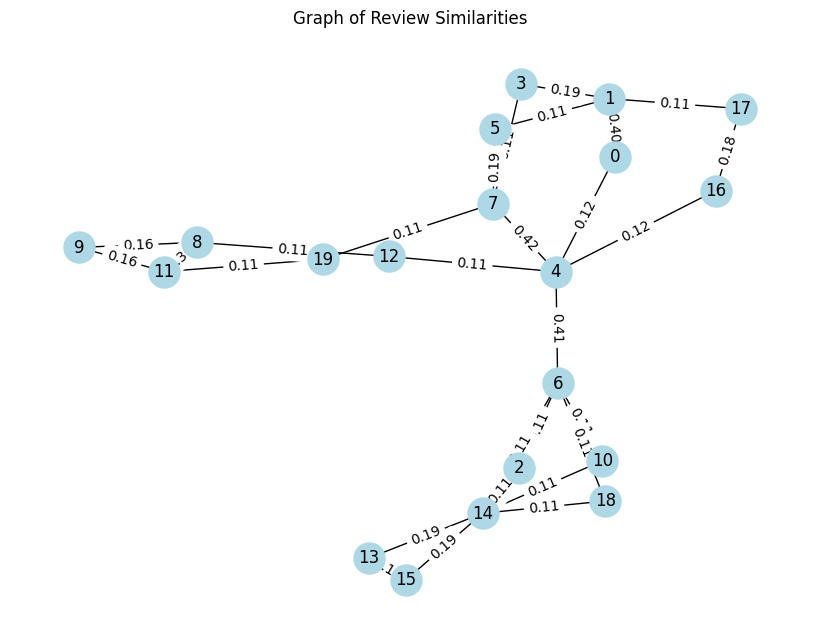

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

pos = nx.spring_layout(G, seed=42)

nx.draw(G, pos, with_labels=True, node_color='lightblue', node_size=500)

edge_labels = nx.get_edge_attributes(G, 'weight')
edge_labels = {k: f"{v:.2f}" for k, v in edge_labels.items()}

nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)

plt.title("Graph of Review Similarities")
plt.show()

In [9]:
from networkx.algorithms import community

communities = community.greedy_modularity_communities(G)

community_list = [list(c) for c in communities]

for i, c in enumerate(community_list):
    print(f"Community {i}: {c}")

Community 0: [0, 1, 3, 4, 5, 7, 12, 16, 17]
Community 1: [2, 18, 6, 10, 13, 14, 15]
Community 2: [8, 9, 11, 19]


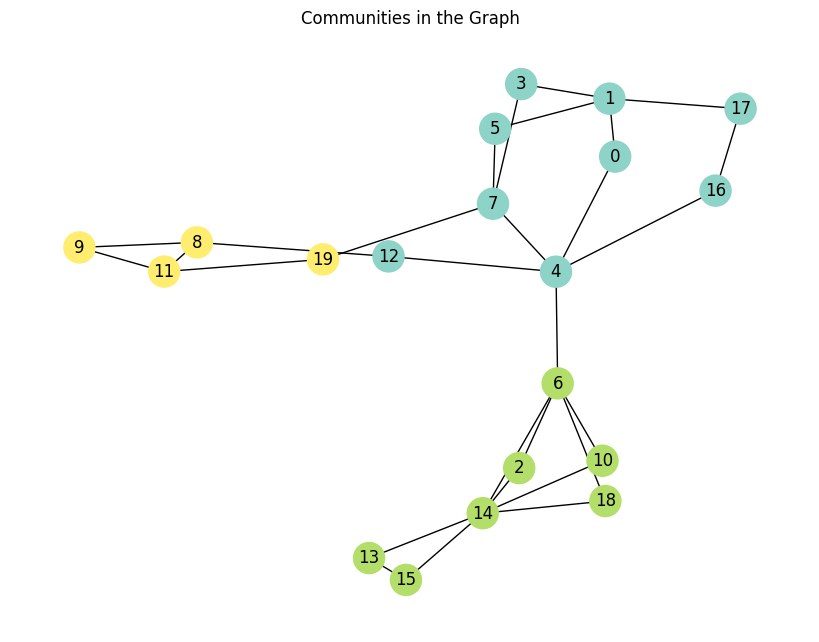

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

pos = nx.spring_layout(G, seed=42)

color_map = {}
for i, community_nodes in enumerate(community_list):
    for node in community_nodes:
        color_map[node] = i

node_colors = [color_map[node] for node in G.nodes()]

nx.draw(G, pos, with_labels=True, node_color=node_colors, cmap=plt.cm.Set3, node_size=500)

plt.title("Communities in the Graph")
plt.show()

In [11]:
pagerank_scores = nx.pagerank(G, weight="weight")

pagerank_df = pd.DataFrame({
    "review_id": list(pagerank_scores.keys()),
    "pagerank_score": list(pagerank_scores.values())
}).sort_values(by="pagerank_score", ascending=False)

pagerank_df

,review_id,pagerank_score
4,4,0.107688
14,14,0.086875
6,6,0.082604
7,7,0.078583
1,1,0.078240
11,11,0.065587
8,8,0.065475
0,0,0.049141
13,13,0.043281
15,15,0.043281


In [12]:
print("Top 5 most central reviews based on PageRank:\n")

top_5 = pagerank_df.head(5)

for _, row in top_5.iterrows():
    review_id = int(row["review_id"])
    score = row["pagerank_score"]
    text = df.loc[df["review_id"] == review_id, "text"].values[0]
    
    print(f"Review {review_id}: {score:.4f}")
    print(f"Text: {text}\n")

Top 5 most central reviews based on PageRank:

Review 4: 0.1077
Text: I like salmon tuna shrimp crab

Review 14: 0.0869
Text: I love curry rice noodles ramen

Review 6: 0.0826
Text: I love sushi tuna salmon seaweed

Review 7: 0.0786
Text: I prefer shrimp crab lobster garlic

Review 1: 0.0782
Text: I enjoy banana orange mango papaya



In [13]:
print("Top review in each community:\n")

for i, community_nodes in enumerate(community_list):
    community_scores = {node: pagerank_scores[node] for node in community_nodes}
    top_node = max(community_scores, key=community_scores.get)
    top_score = community_scores[top_node]
    top_text = df.loc[df["review_id"] == top_node, "text"].values[0]
    
    print(f"Community {i}")
    print(f"Top review: {top_node}")
    print(f"Score: {top_score:.4f}")
    print(f"Text: {top_text}\n")

Top review in each community:

Community 0
Top review: 4
Score: 0.1077
Text: I like salmon tuna shrimp crab

Community 1
Top review: 14
Score: 0.0869
Text: I love curry rice noodles ramen

Community 2
Top review: 11
Score: 0.0656
Text: I prefer roast beef pork chop

